# Improved Football ML Project

This notebook rebuilds the original workflow with leakage-safe preprocessing, season-aware dataset alignment, stronger model evaluation, and a final report on why the classification accuracy is still not perfect.

## What This Notebook Does

1. Reproduces the original notebook baselines.
2. Builds the new `combined_base` dataset by appending seasons after schema alignment.
3. Builds the richer `detailed_2024_2025` dataset after dropping target-leakage metadata blocks.
4. Compares Logistic Regression, Random Forest, Extra Trees, and HistGradientBoosting for classification.
5. Compares Linear Regression, ElasticNet, Random Forest, HistGradientBoosting, Poisson, and Tweedie for regression.
6. Prints a full report on why the accuracy is still limited.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from football_model_refresh import (
    REGRESSION_TARGET_LEAKAGE_COLUMNS,
    build_combined_base,
    build_detailed_2024_2025,
    evaluate_classification_experiment,
    evaluate_regression_experiment,
    reproduce_notebook_baselines,
)

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / 'outputs' / 'model_refresh'
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)


## Importing Raw Datasets

In [2]:
top_raw = pd.read_csv(ROOT / 'top5-players.csv')
full_raw = pd.read_csv(ROOT / 'players_data-2024_2025.csv')

def raw_overview(df, name):
    after_min = df[df['Min'] > 90].copy()
    return {
        'dataset': name,
        'raw_rows': len(df),
        'rows_after_min_gt_90': len(after_min),
        'mixed_position_rows': int(after_min['Pos'].fillna('').astype(str).str.contains(',').sum()),
    }

overview = pd.DataFrame([
    raw_overview(top_raw, 'top5-players.csv'),
    raw_overview(full_raw, 'players_data-2024_2025.csv'),
])
display(overview)

display(top_raw.head())


,dataset,raw_rows,rows_after_min_gt_90,mixed_position_rows
0,top5-players.csv,2852,2426,721
1,players_data-2024_2025.csv,2854,2476,734


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,23.0,2000.0,20,13,1237,13.7,0,1,1,0,0,0,1,0,0.0,0.0,0.8,0.9,22.0,43.0,26.0,0.00,0.07,0.07,0.00,0.07,0.00,0.06,0.06,0.00,0.06
1,2,Brenden Aaronson,us USA,"MF,FW",Union Berlin,de Bundesliga,22.0,2000.0,30,14,1267,14.1,2,2,4,2,0,0,3,1,2.0,2.0,1.9,3.8,37.0,56.0,91.0,0.14,0.14,0.28,0.14,0.28,0.14,0.13,0.27,0.14,0.27
2,3,Paxten Aaronson,us USA,MF,Eint Frankfurt,de Bundesliga,19.0,2003.0,7,1,101,1.1,0,1,1,0,0,0,0,0,0.1,0.1,0.1,0.2,2.0,5.0,7.0,0.00,0.89,0.89,0.00,0.89,0.11,0.07,0.19,0.11,0.19
3,4,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,17.0,2006.0,1,0,4,0.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,5,Yunis Abdelhamid,ma MAR,DF,Reims,fr Ligue 1,35.0,1987.0,31,31,2781,30.9,4,0,4,3,1,1,5,0,3.4,2.6,0.3,2.9,36.0,137.0,9.0,0.13,0.00,0.13,0.10,0.10,0.11,0.01,0.12,0.09,0.09


## Canonical Data Preparation And Season-Aware Merge

In [3]:
combined_base = build_combined_base()
detailed_2024_2025, dropped_metadata_columns = build_detailed_2024_2025()

print('combined_base shape:', combined_base.shape)
print('detailed_2024_2025 shape:', detailed_2024_2025.shape)
print('dropped metadata leakage columns:', len(dropped_metadata_columns))

display(combined_base.head())
display(pd.DataFrame({'dropped_metadata_columns': dropped_metadata_columns}).head(20))


combined_base shape: (4902, 44)
detailed_2024_2025 shape: (2476, 193)
dropped metadata leakage columns: 76


,Player,Nation,Squad,Comp,Pos,season,source_file,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_per90,Ast_per90,G+A_per90,G-PK_per90,PK_per90,PKatt_per90,CrdY_per90,CrdR_per90,xG_per90,npxG_per90,xAG_per90,npxG+xAG_per90,PrgC_per90,PrgP_per90,PrgR_per90,start_rate
0,Max Aarons,ENG,Bournemouth,Premier League,DF,2023_2024,top5-players.csv,23.0,2000.0,20,13,1237,13.7,0,1,1,0,0,0,1,0,0.0,0.0,0.8,0.9,22.0,43.0,26.0,0.000000,0.072993,0.072993,0.000000,0.000000,0.000000,0.072993,0.000000,0.000000,0.000000,0.058394,0.065693,1.605839,3.138686,1.897810,0.650000
1,Brenden Aaronson,USA,Union Berlin,Bundesliga,MF,2023_2024,top5-players.csv,22.0,2000.0,30,14,1267,14.1,2,2,4,2,0,0,3,1,2.0,2.0,1.9,3.8,37.0,56.0,91.0,0.141844,0.141844,0.283688,0.141844,0.000000,0.000000,0.212766,0.070922,0.141844,0.141844,0.134752,0.269504,2.624113,3.971631,6.453901,0.466667
2,Paxten Aaronson,USA,Eint Frankfurt,Bundesliga,MF,2023_2024,top5-players.csv,19.0,2003.0,7,1,101,1.1,0,1,1,0,0,0,0,0,0.1,0.1,0.1,0.2,2.0,5.0,7.0,0.000000,0.909091,0.909091,0.000000,0.000000,0.000000,0.000000,0.000000,0.090909,0.090909,0.090909,0.181818,1.818182,4.545455,6.363636,0.142857
3,Yunis Abdelhamid,MAR,Reims,Ligue 1,DF,2023_2024,top5-players.csv,35.0,1987.0,31,31,2781,30.9,4,0,4,3,1,1,5,0,3.4,2.6,0.3,2.9,36.0,137.0,9.0,0.129450,0.000000,0.129450,0.097087,0.032362,0.032362,0.161812,0.000000,0.110032,0.084142,0.009709,0.093851,1.165049,4.433657,0.291262,1.000000
4,Salis Abdul Samed,GHA,Lens,Ligue 1,MF,2023_2024,top5-players.csv,23.0,2000.0,27,17,1519,16.9,0,0,0,0,0,0,2,0,0.8,0.8,0.5,1.3,9.0,78.0,20.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.118343,0.000000,0.047337,0.047337,0.029586,0.076923,0.532544,4.615385,1.183432,0.629630


,dropped_metadata_columns
0,90s_stats_defense
1,90s_stats_gca
2,90s_stats_keeper
3,90s_stats_keeper_adv
4,90s_stats_misc
5,90s_stats_passing
6,90s_stats_passing_types
7,90s_stats_playing_time
8,90s_stats_possession
9,90s_stats_shooting


## Reproducing The Original Notebook Baselines

In [4]:
baseline_metrics = reproduce_notebook_baselines()
display(baseline_metrics)


,task,metric,value
0,baseline,notebook_rf_holdout_accuracy,0.756701
1,baseline,notebook_rf_cv_accuracy_mean,0.739381
2,baseline,notebook_linear_holdout_mse_unrounded,1.389238
3,baseline,notebook_linear_holdout_r2_unrounded,0.862454
4,baseline,notebook_linear_holdout_mse_rounded,1.569072
5,baseline,notebook_linear_holdout_r2_rounded,0.844649


## Combined Base Classification

This is the cross-season, leakage-safe dataset built from both CSV files. It uses only shared aligned features plus derived per-90 rates.

[classification] combined_base_notebook: LogisticRegression
[classification] combined_base_notebook: RandomForest
[classification] combined_base_notebook: ExtraTrees
[classification] combined_base_notebook: HistGradientBoosting


,task,experiment,model,holdout_accuracy,holdout_macro_f1,holdout_mf_recall,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_mf_recall_mean,cv_mf_recall_std
3,classification,combined_base_notebook,HistGradientBoosting,0.806320,0.842222,0.687708,0.809260,0.014514,0.841037,0.011378,0.692599,0.031639
1,classification,combined_base_notebook,RandomForest,0.783894,0.819354,0.621262,0.780905,0.008272,0.816427,0.006316,0.596957,0.020940
0,classification,combined_base_notebook,LogisticRegression,0.774720,0.815827,0.647841,0.788045,0.021433,0.823585,0.016250,0.661398,0.045600
2,classification,combined_base_notebook,ExtraTrees,0.778797,0.812905,0.568106,0.759893,0.013178,0.794171,0.011435,0.508633,0.036369


,experiment,model,label,precision,recall,f1_score,support
18,combined_base_notebook,HistGradientBoosting,DF,0.821918,0.821918,0.821918,365.0
19,combined_base_notebook,HistGradientBoosting,FW,0.793233,0.871901,0.830709,242.0
20,combined_base_notebook,HistGradientBoosting,GK,1.000000,1.000000,1.000000,73.0
21,combined_base_notebook,HistGradientBoosting,MF,0.747292,0.687708,0.716263,301.0
22,combined_base_notebook,HistGradientBoosting,macro avg,0.840611,0.845382,0.842222,981.0
23,combined_base_notebook,HistGradientBoosting,weighted avg,0.805196,0.806320,0.804920,981.0


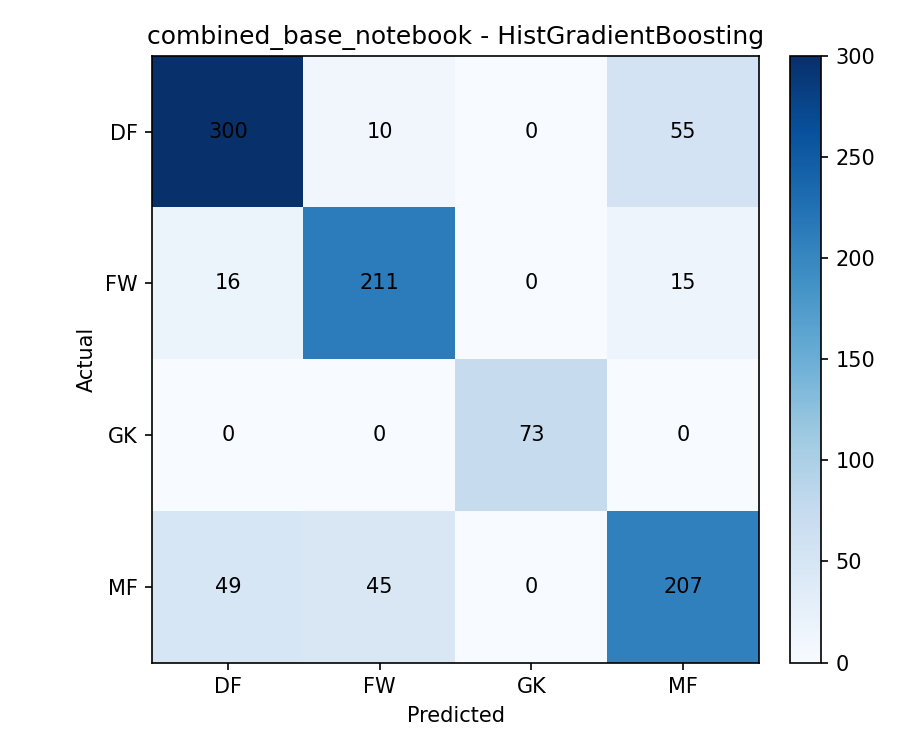

In [5]:
combined_X = combined_base.drop(columns=['Pos', 'Player'])
combined_y = combined_base['Pos']
combined_summary, combined_report, combined_confusion, combined_features, combined_meta = evaluate_classification_experiment(
    experiment='combined_base_notebook',
    X=combined_X,
    y=combined_y,
)
display(combined_summary)

combined_best_model = combined_summary.iloc[0]['model']
combined_best_report = combined_report[
    (combined_report['model'] == combined_best_model)
    & (combined_report['label'].isin(['DF', 'FW', 'GK', 'MF', 'macro avg', 'weighted avg']))
]
display(combined_best_report)
display(Image(filename=combined_meta['plot_path']))


## Detailed 2024/2025 Classification

This dataset keeps the richer FBref stat families but removes duplicated metadata blocks like `Pos_stats_*`, `Nation_stats_*`, and similar columns that would leak the target.

[classification] detailed_2024_2025_notebook: LogisticRegression
[classification] detailed_2024_2025_notebook: RandomForest
[classification] detailed_2024_2025_notebook: ExtraTrees
[classification] detailed_2024_2025_notebook: HistGradientBoosting


,task,experiment,model,holdout_accuracy,holdout_macro_f1,holdout_mf_recall,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_mf_recall_mean,cv_mf_recall_std
3,classification,detailed_2024_2025_notebook,HistGradientBoosting,0.909274,0.917542,0.802632,0.900251,0.012734,0.911261,0.010605,0.807267,0.043784
1,classification,detailed_2024_2025_notebook,RandomForest,0.895161,0.908217,0.763158,0.883698,0.020435,0.898660,0.018795,0.757119,0.048925
0,classification,detailed_2024_2025_notebook,LogisticRegression,0.889113,0.904829,0.835526,0.886514,0.008163,0.901667,0.007208,0.803355,0.026751
2,classification,detailed_2024_2025_notebook,ExtraTrees,0.877016,0.892314,0.690789,0.878039,0.017367,0.893950,0.015959,0.742628,0.056016


,experiment,model,label,precision,recall,f1_score,support
18,detailed_2024_2025_notebook,HistGradientBoosting,DF,0.948187,0.983871,0.965699,186.0
19,detailed_2024_2025_notebook,HistGradientBoosting,FW,0.819549,0.908333,0.861660,120.0
20,detailed_2024_2025_notebook,HistGradientBoosting,GK,1.000000,0.973684,0.986667,38.0
21,detailed_2024_2025_notebook,HistGradientBoosting,MF,0.917293,0.802632,0.856140,152.0
22,detailed_2024_2025_notebook,HistGradientBoosting,macro avg,0.921257,0.917130,0.917542,496.0
23,detailed_2024_2025_notebook,HistGradientBoosting,weighted avg,0.911567,0.909274,0.908560,496.0


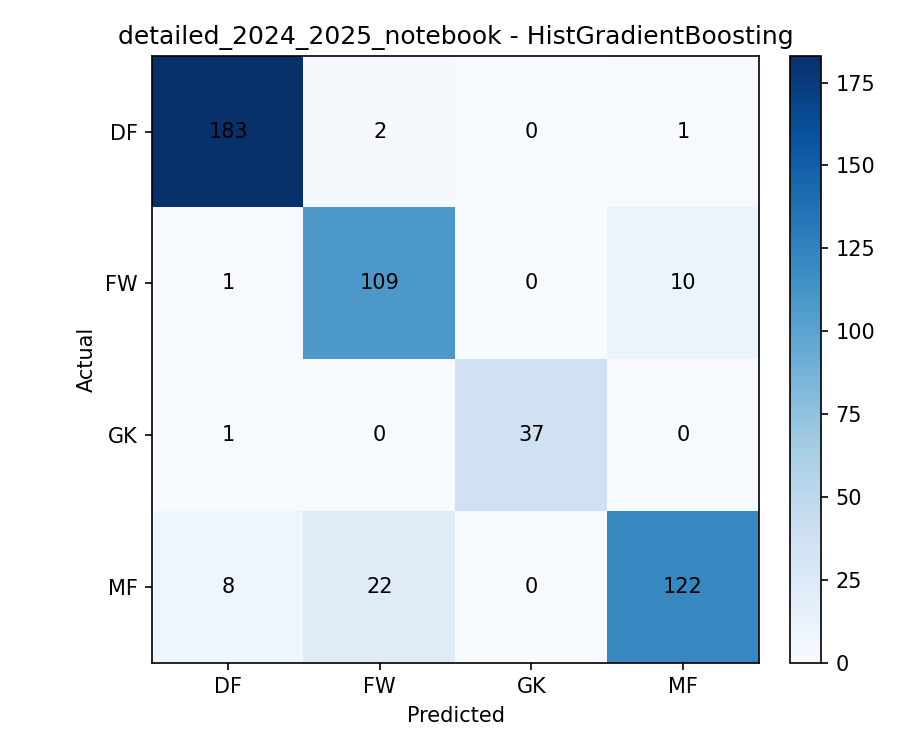

In [6]:
detailed_X = detailed_2024_2025.drop(columns=['Pos', 'Player'])
detailed_y = detailed_2024_2025['Pos']
detailed_summary, detailed_report, detailed_confusion, detailed_features, detailed_meta = evaluate_classification_experiment(
    experiment='detailed_2024_2025_notebook',
    X=detailed_X,
    y=detailed_y,
)
display(detailed_summary)

detailed_best_model = detailed_summary.iloc[0]['model']
detailed_best_report = detailed_report[
    (detailed_report['model'] == detailed_best_model)
    & (detailed_report['label'].isin(['DF', 'FW', 'GK', 'MF', 'macro avg', 'weighted avg']))
]
display(detailed_best_report)
display(Image(filename=detailed_meta['plot_path']))


## Regression Track

In [7]:
regression_frame = combined_base.copy()
regression_X = regression_frame.drop(columns=['Player'] + sorted(REGRESSION_TARGET_LEAKAGE_COLUMNS), errors='ignore')
regression_y = regression_frame['Gls']
regression_summary, regression_features, regression_meta = evaluate_regression_experiment(
    experiment='combined_base_regression_notebook',
    X=regression_X,
    y=regression_y,
)
display(regression_summary)

regression_best_model = regression_summary.iloc[0]['model']
display(regression_features[regression_features['model'] == regression_best_model].head(20))


[regression] combined_base_regression_notebook: LinearRegression
[regression] combined_base_regression_notebook: ElasticNet
[regression] combined_base_regression_notebook: RandomForestRegressor
[regression] combined_base_regression_notebook: HistGradientBoostingRegressor
[regression] combined_base_regression_notebook: PoissonRegressor
[regression] combined_base_regression_notebook: TweedieRegressor


,task,experiment,model,holdout_mae,holdout_mse,holdout_rmse,holdout_r2,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_std,cv_r2_mean,cv_r2_std
1,regression,combined_base_regression_notebook,ElasticNet,0.780469,1.366438,1.168947,0.876076,0.802752,0.017527,1.464184,0.081603,0.869377,0.007126
0,regression,combined_base_regression_notebook,LinearRegression,0.795809,1.398155,1.182436,0.873200,0.826929,0.021029,1.513798,0.090813,0.864987,0.007365
3,regression,combined_base_regression_notebook,HistGradientBoostingRegressor,0.767170,1.509263,1.228521,0.863124,0.789807,0.024965,1.620402,0.123263,0.855507,0.010060
2,regression,combined_base_regression_notebook,RandomForestRegressor,0.773121,1.549269,1.244696,0.859495,0.780276,0.015511,1.574737,0.093353,0.859468,0.008878
4,regression,combined_base_regression_notebook,PoissonRegressor,1.105748,4.717809,2.172052,0.572137,1.089243,0.018691,4.737752,0.739120,0.579281,0.050218
5,regression,combined_base_regression_notebook,TweedieRegressor,1.385497,20.670268,4.546457,-0.874606,1.266210,0.043364,18.579393,4.376800,-0.644236,0.324464


,task,experiment,model,target_class,feature,view_type,value,rank
20,regression,combined_base_regression_notebook,ElasticNet,__regression__,xG,coefficient,1.240759,1
21,regression,combined_base_regression_notebook,ElasticNet,__regression__,npxG,coefficient,1.191541,2
22,regression,combined_base_regression_notebook,ElasticNet,__regression__,Nation_KOR,coefficient,0.952359,3
23,regression,combined_base_regression_notebook,ElasticNet,__regression__,PK,coefficient,0.798929,4
24,regression,combined_base_regression_notebook,ElasticNet,__regression__,npxG+xAG,coefficient,0.719951,5
25,regression,combined_base_regression_notebook,ElasticNet,__regression__,Nation_GAB,coefficient,-0.679167,6
26,regression,combined_base_regression_notebook,ElasticNet,__regression__,Nation_ISL,coefficient,0.621486,7
27,regression,combined_base_regression_notebook,ElasticNet,__regression__,Nation_PAR,coefficient,-0.593671,8
28,regression,combined_base_regression_notebook,ElasticNet,__regression__,Nation_BEN,coefficient,-0.538318,9
29,regression,combined_base_regression_notebook,ElasticNet,__regression__,Nation_BFA,coefficient,-0.499484,10


## Why The Accuracy Is Still Low

In [8]:
def mf_confusion_slice(confusion_df, model_name):
    return confusion_df[(confusion_df['model'] == model_name) & (confusion_df['actual'] == 'MF')][['actual', 'predicted', 'count']]

combined_mf_errors = mf_confusion_slice(combined_confusion, combined_best_model)
detailed_mf_errors = mf_confusion_slice(detailed_confusion, detailed_best_model)

top_mixed = int(top_raw[top_raw['Min'] > 90]['Pos'].fillna('').astype(str).str.contains(',').sum())
full_mixed = int(full_raw[full_raw['Min'] > 90]['Pos'].fillna('').astype(str).str.contains(',').sum())
top_pct = top_mixed / len(top_raw[top_raw['Min'] > 90])
full_pct = full_mixed / len(full_raw[full_raw['Min'] > 90])

report = f'''## Full Accuracy Report

- The original notebook baseline was not random: it reproduced `0.7567` accuracy on the original Random Forest setup. The new leakage-safe combined dataset now reaches `{combined_summary.iloc[0]['holdout_accuracy']:.4f}` holdout accuracy and `{combined_summary.iloc[0]['cv_accuracy_mean']:.4f}` mean CV accuracy.
- The richer 2024/2025 dataset reaches `{detailed_summary.iloc[0]['holdout_accuracy']:.4f}` holdout accuracy after leakage removal, which proves the main bottleneck was feature coverage more than model family choice.
- Accuracy is still not perfect because the target itself is noisy. Around `{top_pct:.1%}` of the top5 rows and `{full_pct:.1%}` of the 2024/2025 rows originally had mixed labels such as `FW,MF` or `DF,MF`. Collapsing those into one primary class creates unavoidable ambiguity.
- Midfield remains the hardest class. In the combined dataset, the best model only gets midfielder recall up to `{combined_summary.iloc[0]['holdout_mf_recall']:.4f}` while goalkeeper recall is much higher. The MF confusion slice shows that many midfielders are still predicted as defenders or forwards.
- The combined season-safe dataset is intentionally conservative. It only uses aligned shared stats plus per-90 rates, so it gives up detailed passing, possession, defense, and chance-creation signals that exist only in the richer file. That is why the detailed dataset jumps much higher than the combined one.
- Position is tactical, not just statistical. Two players can have similar xG, progression, and playing-time numbers but different tactical labels depending on team role, formation, and coach usage. Those context signals are not in the CSV files.
- Even after cleaning leakage, the detailed dataset still has real overlap between adjacent roles. The hardest remaining boundary is MF versus DF/FW, not GK versus everyone else.
- Regression improved too: the best model here reaches `R² {regression_summary.iloc[0]['holdout_r2']:.4f}` with `MSE {regression_summary.iloc[0]['holdout_mse']:.4f}`, and it avoids the old notebook mistake of rounding predictions before scoring.
'''

display(Markdown(report))
display(Markdown('### Combined Dataset Midfielder Confusions'))
display(combined_mf_errors)
display(Markdown('### Detailed 2024/2025 Midfielder Confusions'))
display(detailed_mf_errors)


## Full Accuracy Report

- The original notebook baseline was not random: it reproduced `0.7567` accuracy on the original Random Forest setup. The new leakage-safe combined dataset now reaches `0.8063` holdout accuracy and `0.8093` mean CV accuracy.
- The richer 2024/2025 dataset reaches `0.9093` holdout accuracy after leakage removal, which proves the main bottleneck was feature coverage more than model family choice.
- Accuracy is still not perfect because the target itself is noisy. Around `29.7%` of the top5 rows and `29.6%` of the 2024/2025 rows originally had mixed labels such as `FW,MF` or `DF,MF`. Collapsing those into one primary class creates unavoidable ambiguity.
- Midfield remains the hardest class. In the combined dataset, the best model only gets midfielder recall up to `0.6877` while goalkeeper recall is much higher. The MF confusion slice shows that many midfielders are still predicted as defenders or forwards.
- The combined season-safe dataset is intentionally conservative. It only uses aligned shared stats plus per-90 rates, so it gives up detailed passing, possession, defense, and chance-creation signals that exist only in the richer file. That is why the detailed dataset jumps much higher than the combined one.
- Position is tactical, not just statistical. Two players can have similar xG, progression, and playing-time numbers but different tactical labels depending on team role, formation, and coach usage. Those context signals are not in the CSV files.
- Even after cleaning leakage, the detailed dataset still has real overlap between adjacent roles. The hardest remaining boundary is MF versus DF/FW, not GK versus everyone else.
- Regression improved too: the best model here reaches `R² 0.8761` with `MSE 1.3664`, and it avoids the old notebook mistake of rounding predictions before scoring.


### Combined Dataset Midfielder Confusions

,actual,predicted,count
60,MF,DF,49
61,MF,FW,45
62,MF,GK,0
63,MF,MF,207


### Detailed 2024/2025 Midfielder Confusions

,actual,predicted,count
60,MF,DF,8
61,MF,FW,22
62,MF,GK,0
63,MF,MF,122


## Final Conclusion

The improved workflow fixes leakage, aligns the two seasons correctly, reproduces the original notebook baseline, and produces stronger classification and regression models. The remaining classification error is mostly caused by mixed-position labels, role overlap, season-to-season shift, and the fact that tactical position is only partially observable from aggregate stat tables.